<a href="https://colab.research.google.com/github/Johan-pp/Clase-S15/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [2]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos
!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "HON","ABT","JPM"

datos = yf.download(
    ticker,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=False
)

datos.head(5)

[*********************100%***********************]  3 of 3 completed


Price        Adj Close                               Close              \
Ticker             ABT         HON         JPM         ABT         HON   
Date                                                                     
2024-01-02  103.769417  195.308731  162.278275  109.849998  206.590439   
2024-01-03  103.457687  191.131531  161.570999  109.519997  202.171967   
2024-01-04  104.836868  191.477310  162.643188  110.980003  202.537704   
2024-01-05  104.666840  190.197067  163.459244  110.800003  201.183502   
2024-01-08  106.178276  189.384064  163.222015  112.400002  200.323532   

Price                         High                                 Low  \
Ticker             JPM         ABT         HON         JPM         ABT   
Date                                                                     
2024-01-02  172.080002  111.000000  208.181870  172.169998  109.559998   
2024-01-03  171.330002  110.250000  206.017120  172.039993  109.290001   
2024-01-04  171.410004  111.029999  203.842484  173.350006  109.510002   
2024-01-05  172.270004  111.050003  202.211502  173.380005  110.029999   
2024-01-08  172.020004  112.519997  201.203262  172.360001  110.919998   

Price                                     Open                          \
Ticker             HON         JPM         ABT         HON         JPM   
Date                                                                     
2024-01-02  205.918274  168.910004  109.559998  206.452042  169.089996   
2024-01-03  201.905075  170.369995  110.139999  206.017120  171.860001   
2024-01-04  201.677734  170.539993  109.680000  201.766693  170.639999   
2024-01-05  199.928131  171.470001  110.709999  202.033585  171.470001   
2024-01-08  198.929779  169.490005  111.129997  200.778229  172.020004   

Price        Volume                     
Ticker          ABT      HON       JPM  
Date                                    
2024-01-02  5058600  3169238   9977400  
2024-01-03  4239600  3858485   9852300  
2024-01-04  5296100  2571649  11972500  
2024-01-05  4127700  2713889  10066000  
2024-01-08  5030400  4066887  11229900

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

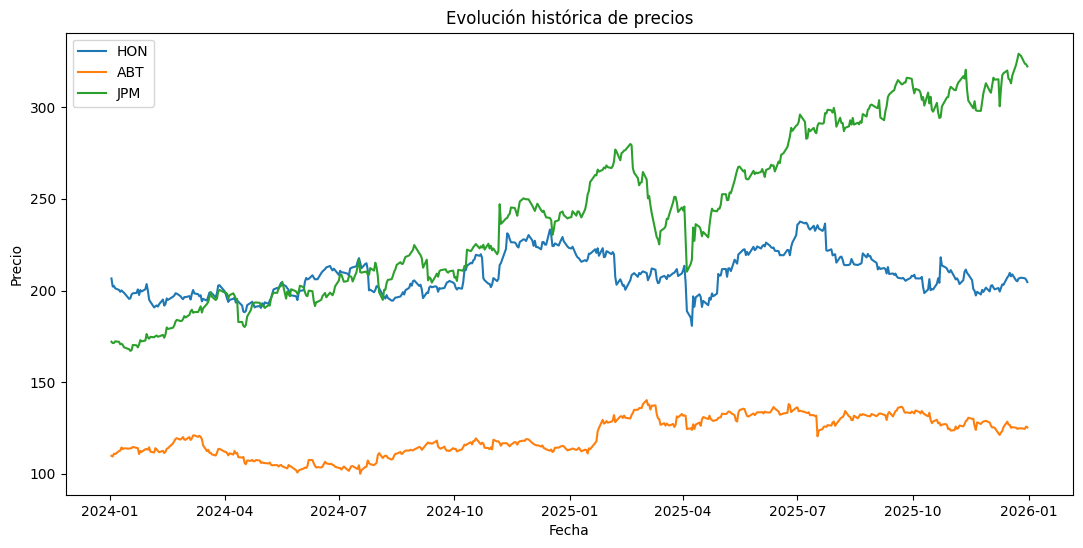

Ticker,ABT,HON,JPM
Date,,,
2024-01-02,100.000000,100.000000,100.000000
2024-01-03,99.699589,97.861241,99.564156
2024-01-04,101.028680,98.038276,99.610647
2024-01-05,100.864820,97.382775,100.110415
2024-01-08,102.321350,96.966507,99.965134


In [7]:
# 1. Extraer los precios de cierre
cierre = datos["Close"]
cierre.head()

# 2. Graficar precios originales
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 6))
for activo in ticker:
    ax.plot(cierre.index, cierre[activo], label=activo)
ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()
plt.show()

# 3. Normalizar y graficar en base 100
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

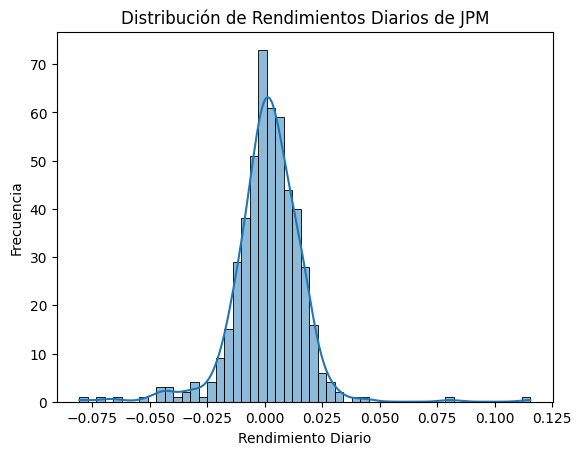

In [8]:
# 1. Calcular rendimientos
rendimiento = cierre.pct_change()
rendimiento.head()
# 2. Histograma con el activo más volátil
import seaborn as sns
import matplotlib.pyplot as plt
# 3. Boxplot comparativo de rendimientos
# Graficar el histograma del activo elegido
sns.histplot(data=rendimiento["JPM"].dropna(), kde=True)
plt.title("Distribución de Rendimientos Diarios de JPM")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Frecuencia")
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Ticker       ABT       HON       JPM
Ticker                              
ABT     1.000000  0.302010  0.176922
HON     0.302010  1.000000  0.407798
JPM     0.176922  0.407798  1.000000


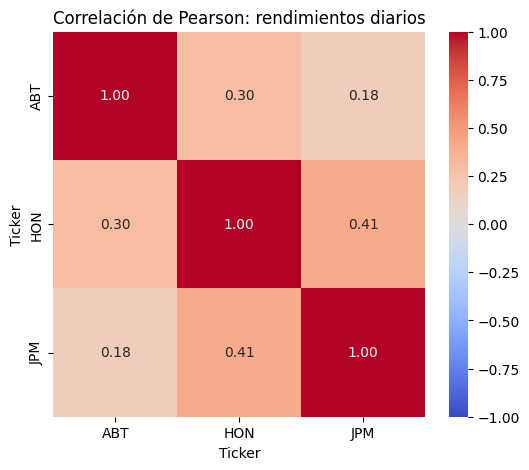

In [9]:
# 1. Calcular matriz de correlación
corr = rendimiento.corr(method="pearson")
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación de Pearson: rendimientos diarios")
plt.show()
# 2. Dibujar el Heatmap utilizando Seaborn

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [13]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
rendimiento.agg(["mean", "median", "std", "min", "max"]).T
resumen.columns = ["Media", "Mediana", "Desv. Estándar", "Mínimo", "Máximo"]
resumen.round(5)

,Media,Mediana,Desv. Estándar,Mínimo,Máximo
Ticker,,,,,
ABT,0.00034,0.00033,0.01275,-0.08524,0.04619
HON,0.00007,-0.00009,0.01360,-0.07591,0.08881
JPM,0.00137,0.00163,0.01527,-0.08050,0.11545
